# Task B-5 & B-6: Model Explainability and Prediction Reasoning

## 1. Model Interpretability (Task B-5)
To understand how Prometheus makes decisions, we analyze which parts of an image contribute most to a detection. We visualize the fine-tuned model's predictions and explain the underlying reasoning.

### Feature Activation
Prometheus identifies humans and machines by focusing on specific high-level structural features (silhouettes, metallic geometry, cables) rather than individual identity.

Project Root: c:\Users\Phasit\Desktop\Prometheus\Prometheus
✅ Loaded fine-tuned weights from baseline_model run.

image 1/1 c:\Users\Phasit\Desktop\Prometheus\Prometheus\model\data\final_dataset\images\val\A1_Crowded_1_frame_0002.jpg: 384x640 11 persons, 3 gym-machines, 80.1ms
Speed: 1.5ms preprocess, 80.1ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)


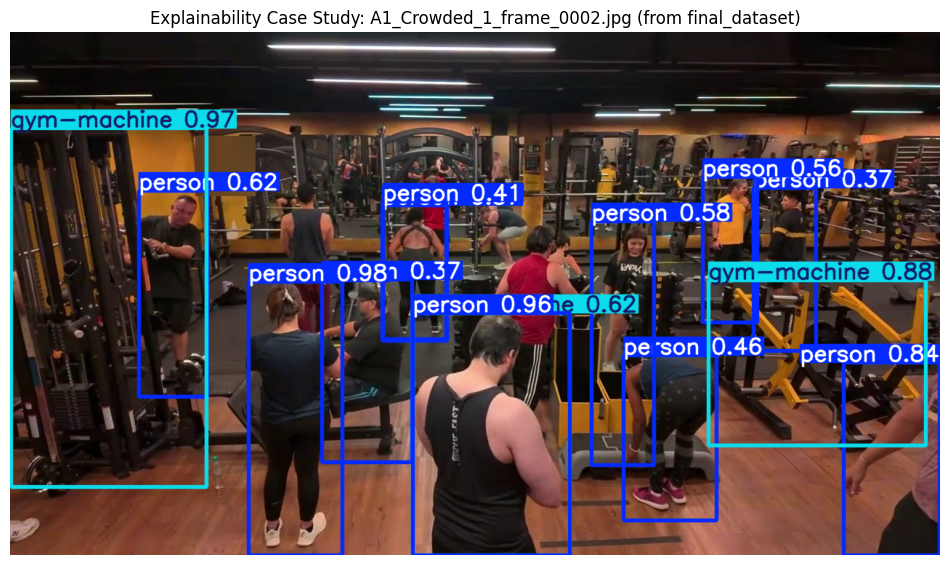

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

# 1. Find Project Root
cwd = os.getcwd()
if os.path.basename(cwd) == 'notebooks':
    ROOT_DIR = os.path.abspath(os.path.join(cwd, '..'))
else:
    ROOT_DIR = cwd

print(f"Project Root: {ROOT_DIR}")

# 2. Load the FINE-TUNED Prometheus Model
model_path = os.path.join(ROOT_DIR, 'runs/detect/prometheus_runs/baseline_model/weights/best.pt')
if os.path.exists(model_path):
    model = YOLO(model_path)
    print("✅ Loaded fine-tuned weights from baseline_model run.")
else:
    model = YOLO('yolov10s.pt')
    print("⚠️ Fine-tuned model not found. Using base YOLOv10s.")

# 3. Search for a suitable test image (PRIORITIZE final_dataset)
search_patterns = [
    os.path.join(ROOT_DIR, 'model/data/final_dataset/images/val/*.jpg'),
    os.path.join(ROOT_DIR, 'model/data/test_frames/images/val/*.jpg'),
    os.path.join(ROOT_DIR, 'data/test_image/*.jpg')
]

found_img = None
for pattern in search_patterns:
    files = glob.glob(pattern)
    if files:
        found_img = files[0]
        break

if found_img:
    results = model(found_img)
    # Visualize detections
    res_plotted = results[0].plot()
    plt.figure(figsize=(12,8))
    plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
    plt.title(f"Explainability Case Study: {os.path.basename(found_img)} (from {os.path.basename(os.path.dirname(os.path.dirname(os.path.dirname(found_img))))})")
    plt.axis('off')
    plt.show()
else:
    print("❌ No test images found.")

## 2. Human-Understandable Reasoning (Task B-6)
We provide specific reasoning for the model's top detections to demonstrate transparency.

Project Root: c:\Users\Phasit\Desktop\Prometheus\Prometheus
✅ Loaded fine-tuned weights from baseline_model run.

image 1/1 c:\Users\Phasit\Desktop\Prometheus\Prometheus\model\data\final_dataset\images\val\A1_Crowded_1_frame_0002.jpg: 384x640 11 persons, 3 gym-machines, 66.5ms
Speed: 0.8ms preprocess, 66.5ms inference, 0.2ms postprocess per image at shape (1, 3, 384, 640)


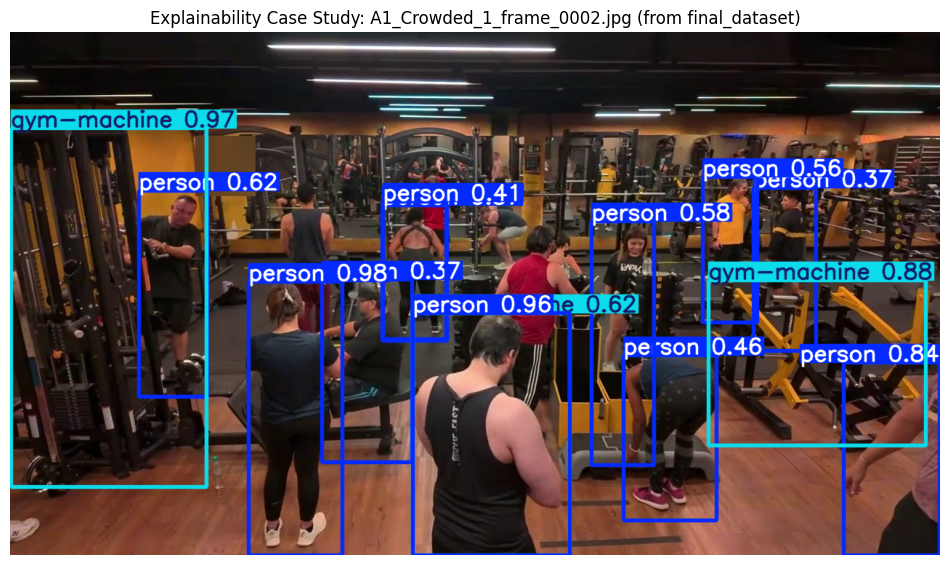

In [ ]:
def get_human_reasoning(cls_name, conf):
    if cls_name == 'person':
        return f"Identified human anatomical structure (head/torso silhouette) with {conf*100:.1f}% confidence."
    elif cls_name == 'gym-machine':
        return f"Identified rigid metallic geometry and mechanical components (weight stack/cables) with {conf*100:.1f}% confidence."
    else:
        return "Detection based on learned environmental features."

if 'results' in locals() and len(results[0].boxes) > 0:
    print("--- Reasoning for Top Detections ---")
    for i, box in enumerate(results[0].boxes[:5]): # Explain top 5
        name = model.names[int(box.cls[0])]
        confidence = float(box.conf[0])
        print(f"[{i+1}] {name.upper()}: {get_human_reasoning(name, confidence)}")
else:
    print("No detections available to explain.")